In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
 
PALETTE = ["#E63946", "#457B9D", "#2A9D8F", "#E9C46A", "#264653"]
sns.set_theme(style="whitegrid")

In [34]:
# LOAD DATA 
df = pd.read_csv(r"C:\Users\Hp\Documents\Internships\Prodigy\Task 2\Mall_Customers.csv")
df.columns = df.columns.str.strip()
print(f"  Rows : {df.shape[0]}  Cols : {df.shape[1]}  Nulls : {df.isnull().sum().sum()}")
print(df.describe().round(2))

  Rows : 200  Cols : 5  Nulls : 0
       CustomerID     Age  Annual Income (k$)  Spending Score (1-100)
count      200.00  200.00              200.00                  200.00
mean       100.50   38.85               60.56                   50.20
std         57.88   13.97               26.26                   25.82
min          1.00   18.00               15.00                    1.00
25%         50.75   28.75               41.50                   34.75
50%        100.50   36.00               61.50                   50.00
75%        150.25   49.00               78.00                   73.00
max        200.00   70.00              137.00                   99.00


In [9]:
df.sample(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
32,33,Male,53,33,4
170,171,Male,40,87,13
104,105,Male,49,62,56
190,191,Female,34,103,23
96,97,Female,47,60,47
117,118,Female,49,65,59
110,111,Male,65,63,52
106,107,Female,66,63,50
30,31,Male,60,30,4
162,163,Male,19,81,5


In [42]:
# FEATURE ENGINEERING  
df["Income_x_Score"] = df["Annual Income (k$)"] * df["Spending Score (1-100)"] / 100
df["Age_Group"]      = pd.cut(df["Age"], bins=[0,25,35,50,100],
                               labels=["18-25", "26-35", "36-50", "51+"])
df.sample(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Income_x_Score,Age_Group
46,47,Female,50,40,55,22.00,36-50
75,76,Male,26,54,54,29.16,26-35
132,133,Female,25,72,34,24.48,18-25
78,79,Female,23,54,52,28.08,18-25
181,182,Female,32,97,86,83.42,26-35


In [44]:
# FEATURE SCALING (StandardScaler)

FEATURES = ["Annual Income (k$)", "Spending Score (1-100)"]
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df[FEATURES])
print(f"  Features scaled : {FEATURES}")
print("  Mean ~ 0 and Std ~ 1 after scaling, prevents income dominating distance")

  Features scaled : ['Annual Income (k$)', 'Spending Score (1-100)']
  Mean ~ 0 and Std ~ 1 after scaling, prevents income dominating distance


In [45]:
# OPTIMAL K SELECTION (Elbow + Silhouette + Davies-Bouldin)
K_RANGE  = range(2, 11)
inertia  = []
sil      = []
db       = []
 
for k in K_RANGE:
    km     = KMeans(n_clusters=k, init="k-means++", n_init=20, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_scaled, labels))
    db.append(davies_bouldin_score(X_scaled, labels))
 
K = 5
print(f"  {'K':>3}  {'Inertia':>10}  {'Silhouette':>12}  {'Davies-Bouldin':>15}")
for i, k in enumerate(K_RANGE):
    mark = "  <-- OPTIMAL" if k == K else ""
    print(f"  {k:>3}  {inertia[i]:>10.2f}  {sil[i]:>12.4f}  {db[i]:>15.4f}{mark}")

    K     Inertia    Silhouette   Davies-Bouldin
    2      269.69        0.3213           1.2670
    3      157.70        0.4666           0.7165
    4      108.92        0.4939           0.7096
    5       65.57        0.5547           0.5722  <-- OPTIMAL
    6       55.06        0.5399           0.6546
    7       44.86        0.5281           0.7148
    8       37.15        0.4567           0.7579
    9       32.39        0.4571           0.7632
   10       29.69        0.4362           0.7645


In [46]:
# K-MEANS CLUSTERING 
km_final   = KMeans(n_clusters=K, init="k-means++", n_init=50, random_state=42)
df["Cluster"] = km_final.fit_predict(X_scaled)
 
print(f"  K            : {K}")
print(f"  Inertia      : {km_final.inertia_:.2f}")
print(f"  Iterations   : {km_final.n_iter_}")
print(f"  Cluster sizes: {df['Cluster'].value_counts().sort_index().to_dict()}")

  K            : 5
  Inertia      : 65.57
  Iterations   : 4
  Cluster sizes: {0: 81, 1: 39, 2: 22, 3: 35, 4: 23}


In [48]:
# CLUSTER EVALUATION (Silhouette + Davies-Bouldin)
final_sil = silhouette_score(X_scaled, df["Cluster"])
final_db  = davies_bouldin_score(X_scaled, df["Cluster"])
 
print(f"  Silhouette Score  : {final_sil:.4f}  (best near 1.0)")
print(f"  Davies-Bouldin    : {final_db:.4f}  (best near 0.0)")

  Silhouette Score  : 0.5547  (best near 1.0)
  Davies-Bouldin    : 0.5722  (best near 0.0)


In [50]:
# DIMENSIONALITY REDUCTION (PCA)
ALL_FEATURES = ["Age", "Annual Income (k$)", "Spending Score (1-100)", "Income_x_Score"]
X_all        = StandardScaler().fit_transform(df[ALL_FEATURES])
 
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_all)
print(f"  PC1 variance : {pca.explained_variance_ratio_[0]:.2%}")
print(f"  PC2 variance : {pca.explained_variance_ratio_[1]:.2%}")
print(f"  Total kept   : {pca.explained_variance_ratio_.sum():.2%}")

  PC1 variance : 51.24%
  PC2 variance : 28.34%
  Total kept   : 79.58%


In [51]:
# SEGMENT LABELLING  
profile    = df.groupby("Cluster")[["Age","Annual Income (k$)","Spending Score (1-100)"]].mean()
profile["Size"] = df.groupby("Cluster").size()
inc_rank   = profile["Annual Income (k$)"].rank()
spend_rank = profile["Spending Score (1-100)"].rank()
 
def assign_label(i):
    inc, spd = inc_rank[i], spend_rank[i]
    if spd >= 4 and inc <= 2: return "Impulsive Spenders"
    if spd >= 4 and inc >= 4: return "Target / Premium"
    if spd <= 2 and inc >= 4: return "Careful High-Earners"
    if spd <= 2 and inc <= 2: return "Budget Conscious"
    return "Standard / Average"
 
profile["Segment"] = [assign_label(i) for i in profile.index]
LABEL_MAP          = profile["Segment"].to_dict()
df["Segment"]      = df["Cluster"].map(LABEL_MAP)
print(profile[["Segment", "Age", "Annual Income (k$)", "Spending Score (1-100)", "Size"]].to_string())

                      Segment        Age  Annual Income (k$)  Spending Score (1-100)  Size
Cluster                                                                                   
0          Standard / Average  42.716049           55.296296               49.518519    81
1            Target / Premium  32.692308           86.538462               82.128205    39
2          Impulsive Spenders  25.272727           25.727273               79.363636    22
3        Careful High-Earners  41.114286           88.200000               17.114286    35
4            Budget Conscious  45.217391           26.304348               20.913043    23


  Saved -> kmeans_customer_segmentation.png


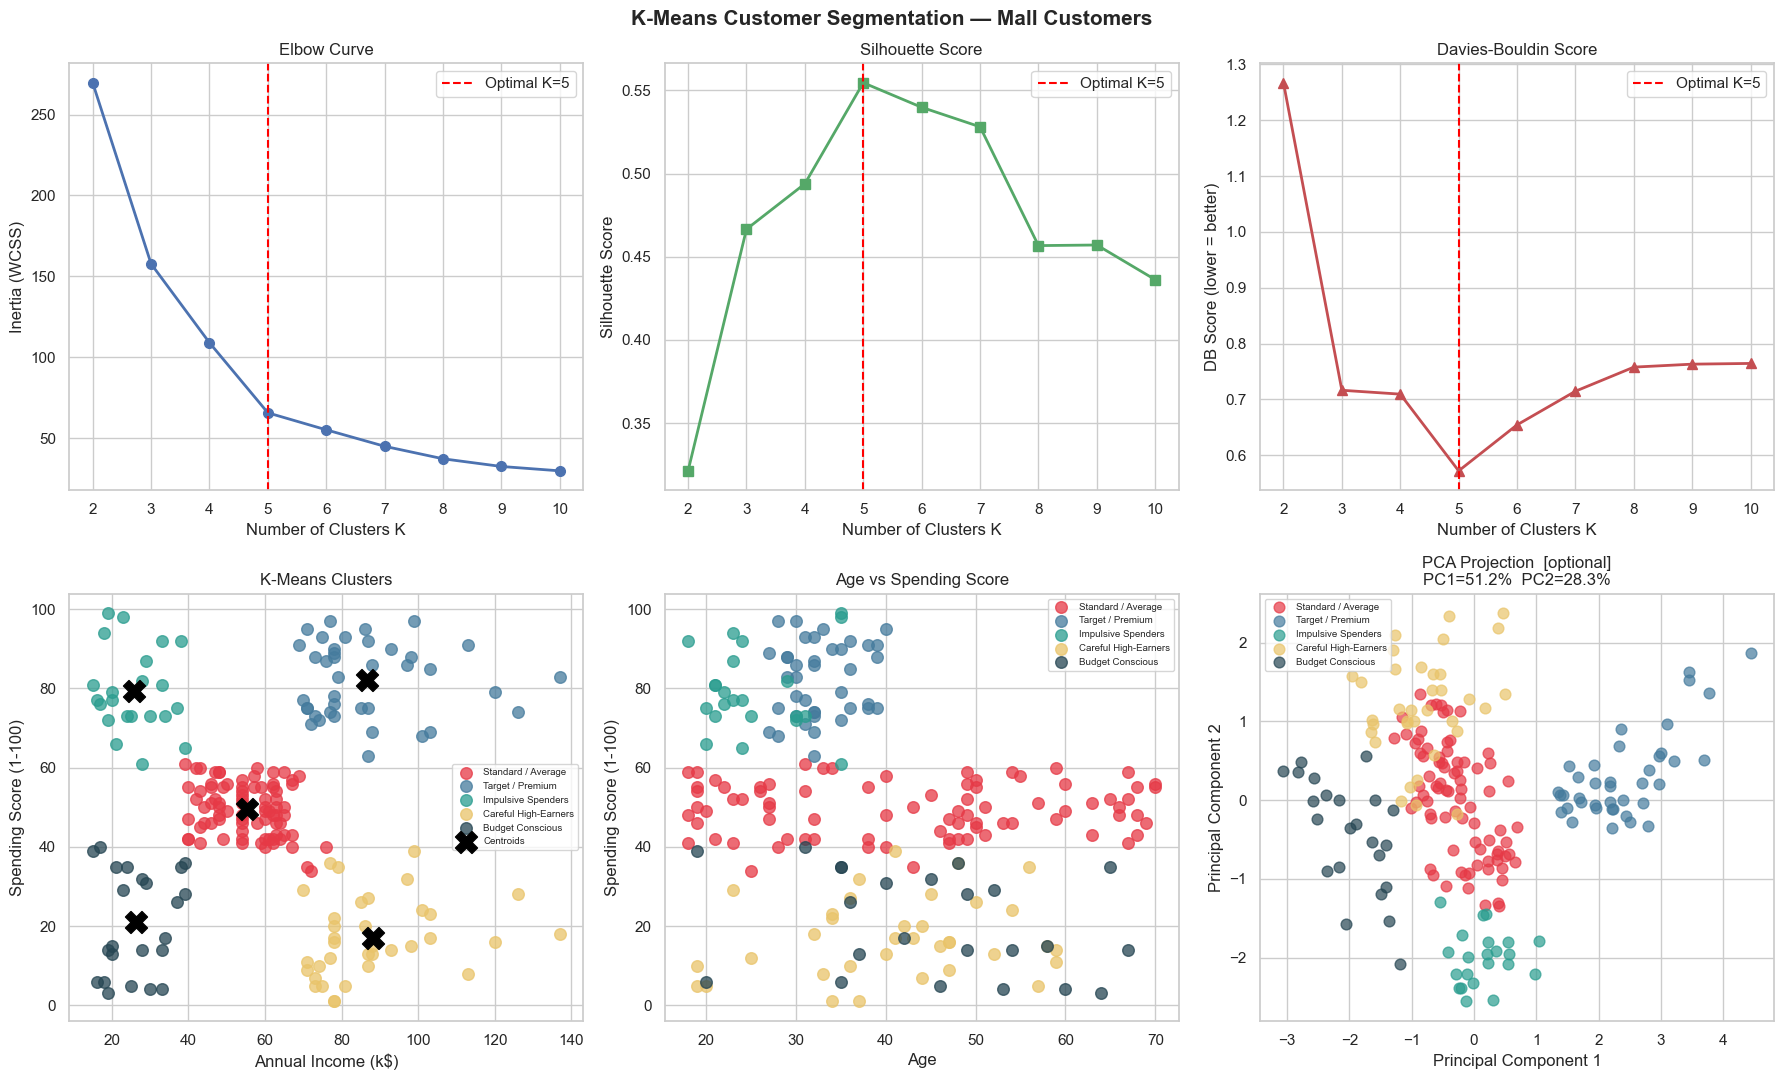

In [53]:
# VISUALISATION  
centroids_inv = scaler.inverse_transform(km_final.cluster_centers_)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("K-Means Customer Segmentation — Mall Customers",
             fontsize=15, fontweight="bold")
 
# (a) Elbow Curve
axes[0,0].plot(list(K_RANGE), inertia, "bo-", lw=2, ms=7)
axes[0,0].axvline(K, color="red", ls="--", lw=1.5, label=f"Optimal K={K}")
axes[0,0].set(title="Elbow Curve",
              xlabel="Number of Clusters K", ylabel="Inertia (WCSS)")
axes[0,0].legend()
 
# (b) Silhouette Score
axes[0,1].plot(list(K_RANGE), sil, "gs-", lw=2, ms=7)
axes[0,1].axvline(K, color="red", ls="--", lw=1.5, label=f"Optimal K={K}")
axes[0,1].set(title="Silhouette Score",
              xlabel="Number of Clusters K", ylabel="Silhouette Score")
axes[0,1].legend()
 
# (c) Davies-Bouldin Score
axes[0,2].plot(list(K_RANGE), db, "r^-", lw=2, ms=7)
axes[0,2].axvline(K, color="red", ls="--", lw=1.5, label=f"Optimal K={K}")
axes[0,2].set(title="Davies-Bouldin Score",
              xlabel="Number of Clusters K", ylabel="DB Score (lower = better)")
axes[0,2].legend()
 
# (d) K-Means Clusters — Income vs Spending Score
for cid in range(K):
    mask = df["Cluster"] == cid
    axes[1,0].scatter(df.loc[mask, "Annual Income (k$)"],
                      df.loc[mask, "Spending Score (1-100)"],
                      s=70, alpha=0.75, color=PALETTE[cid], label=LABEL_MAP[cid])
axes[1,0].scatter(centroids_inv[:, 0], centroids_inv[:, 1],
                  c="black", marker="X", s=250, zorder=5, label="Centroids")
axes[1,0].set(title="K-Means Clusters",
              xlabel="Annual Income (k$)", ylabel="Spending Score (1-100)")
axes[1,0].legend(fontsize=7)
 
# (e) Age vs Spending Score by Cluster
for cid in range(K):
    mask = df["Cluster"] == cid
    axes[1,1].scatter(df.loc[mask, "Age"],
                      df.loc[mask, "Spending Score (1-100)"],
                      s=70, alpha=0.75, color=PALETTE[cid], label=LABEL_MAP[cid])
axes[1,1].set(title="Age vs Spending Score",
              xlabel="Age", ylabel="Spending Score (1-100)")
axes[1,1].legend(fontsize=7)
 
# (f) PCA 2D Projection
for cid in range(K):
    mask = df["Cluster"] == cid
    axes[1,2].scatter(X_pca[mask, 0], X_pca[mask, 1],
                      s=60, alpha=0.7, color=PALETTE[cid], label=LABEL_MAP[cid])
axes[1,2].set(
    title=f"PCA Projection  [optional]\nPC1={pca.explained_variance_ratio_[0]:.1%}  "
          f"PC2={pca.explained_variance_ratio_[1]:.1%}",
    xlabel="Principal Component 1",
    ylabel="Principal Component 2")
axes[1,2].legend(fontsize=7)
plt.tight_layout()
plt.savefig("kmeans_customer_segmentation.png", dpi=150, bbox_inches="tight")
print("  Saved -> kmeans_customer_segmentation.png")

In [56]:
# EXPORT RESULTS
 
df[["Gender", "Age", "Annual Income (k$)", "Spending Score (1-100)",
    "Income_x_Score", "Age_Group", "Cluster", "Segment"]].to_csv(
    r"C:\Users\Hp\Documents\Internships\Prodigy\Task 2\customers_with_segments.csv", index=False)
df.sample(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Income_x_Score,Age_Group,Cluster,Segment
13,14,Female,24,20,77,15.40,18-25,2,Impulsive Spenders
123,124,Male,39,69,91,62.79,36-50,1,Target / Premium
99,100,Male,20,61,49,29.89,18-25,0,Standard / Average
8,9,Male,64,19,3,0.57,51+,4,Budget Conscious
195,196,Female,35,120,79,94.80,26-35,1,Target / Premium
169,170,Male,32,87,63,54.81,26-35,1,Target / Premium
191,192,Female,32,103,69,71.07,26-35,1,Target / Premium
46,47,Female,50,40,55,22.00,36-50,0,Standard / Average
164,165,Male,50,85,26,22.10,36-50,3,Careful High-Earners
137,138,Male,32,73,73,53.29,26-35,1,Target / Premium
